Is SCVI doing the thing? 

In [14]:
import os
import pandas as pd
import re
import numpy as np
import glob
from pathlib import Path
from scipy import sparse
from copy import deepcopy
import csv
import itertools
import warnings
import sys
import scanpy as sc
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt
from scipy.io import mmread
import re
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

In [23]:
adata_scvi_100 = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/out_postproc_scvi/scvi.latent_100/adata.scvi.latent_100.h5ad')

In [24]:
adata_scvi_100

AnnData object with n_obs × n_vars = 59140 × 5000
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', '_scvi_batch', '_scvi_labels', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_gr

In [25]:
adata_scvi_100.obsm['X_scVI'].shape

(59140, 100)

In [26]:
adata_scvi_100.obsm['X_pca'].shape

(59140, 42)

In [27]:
adata_no_scvi.obsm['X_pca'].shape

(59140, 50)

In [16]:
# min_dist = 0.3
sc.pp.neighbors(adata_scvi_100, n_neighbors=30, use_rep='X_scVI')
sc.tl.paga(adata_scvi_100)
sc.pl.paga(adata_scvi_100, plot=False)
sc.tl.umap(adata_scvi_100, init_pos='paga', min_dist=min_dist)

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

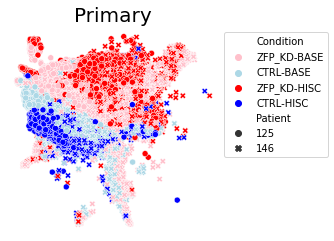

In [17]:
color_labels = {}
for col, i in zip(['blue','red'],['CTRL','ZFP_KD']):
    for shade,j in zip(['light',''],['BASE','HISC']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'


fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata_scvi_100.obs.Tumor_Site=='Primary'
ind2 = adata_scvi_100.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata = adata_scvi_100[ind,:]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

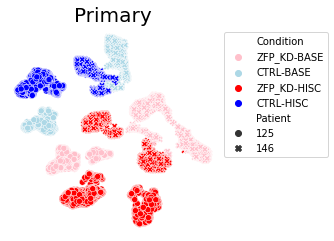

In [18]:
adata_scvi_100 = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/out_postproc_scvi/scvi.latent_100/adata.scvi.latent_100.h5ad')

color_labels = {}
for col, i in zip(['blue','red'],['CTRL','ZFP_KD']):
    for shade,j in zip(['light',''],['BASE','HISC']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'


fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata_scvi_100.obs.Tumor_Site=='Primary'
ind2 = adata_scvi_100.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata = adata_scvi_100[ind,:]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

In [29]:
norm_df = pd.DataFrame(adata_scvi_100.X, index=adata_scvi_100.obs_names, columns = adata_scvi_100.var_names)

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [31]:
norm_df.shape

(59140, 4982)

In [16]:
# What does the plot for no batch corrected adata with 5000 highly variable genes look like? 
adata_no_scvi = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post/adata.combined.postprocessing.h5ad')

adata_no_scvi.obsm['X_pca_all_genes'] = adata_no_scvi.obsm['X_pca']
adata_no_scvi.obs['Batch'] = adata_no_scvi.obs['Batch'].astype('category')
sc.pp.highly_variable_genes(adata_no_scvi, n_top_genes = 5000, batch_key = 'Batch')
sc.pp.pca(adata_no_scvi, use_highly_variable = True)
sc.tl.leiden(adata_no_scvi, resolution = 1.8)
sc.tl.paga(adata_no_scvi, groups = 'phenograph')
sc.pl.paga(adata_no_scvi, plot=False)
min_dist = 0.3
sc.tl.umap(adata_no_scvi, init_pos='paga', min_dist=min_dist)

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pa

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

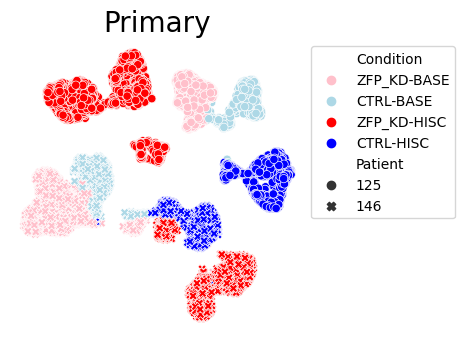

In [19]:
color_labels = {}
for col, i in zip(['blue','red'],['CTRL','ZFP_KD']):
    for shade,j in zip(['light',''],['BASE','HISC']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'


fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata_no_scvi.obs.Tumor_Site=='Primary'
ind2 = adata_no_scvi.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata = adata_no_scvi[ind,:]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

In [62]:
# What does the plot for no batch corrected adata with 5000 highly variable genes look like? 
adata_no_scvi = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post/adata.combined.postprocessing.h5ad')


In [ ]:

adata_no_scvi.obsm['X_pca_all_genes'] = adata_no_scvi.obsm['X_pca']
adata_no_scvi.obs['Batch'] = adata_no_scvi.obs['Batch'].astype('category')
sc.pp.highly_variable_genes(adata_no_scvi, n_top_genes = 5000, batch_key = 'Batch')
sc.pp.pca(adata_no_scvi, use_highly_variable = True)
sc.tl.leiden(adata_no_scvi, resolution = 1.8)
sc.tl.paga(adata_no_scvi, groups = 'phenograph')
sc.pl.paga(adata_no_scvi, plot=False)
min_dist = 0.3
sc.tl.umap(adata_no_scvi, init_pos='paga', min_dist=min_dist)

In [63]:
adata = adata_no_scvi.copy()

In [64]:
counts = pd.DataFrame(adata.raw.X.todense(), index=adata.raw.obs_names, columns=adata.raw.var_names)

In [65]:
adata.layers['counts'] = counts.loc[adata.obs_names, adata.var_names]

In [66]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Batch"
)

In [85]:
sc.pp.pca(adata, use_highly_variable = True)


In [87]:
sc.tl.leiden(adata, resolution = 1.8)
sc.tl.paga(adata, groups = 'leiden')
sc.pl.paga(adata, plot=False)
min_dist = 0.3
sc.tl.umap(adata, init_pos='paga', min_dist=min_dist)

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

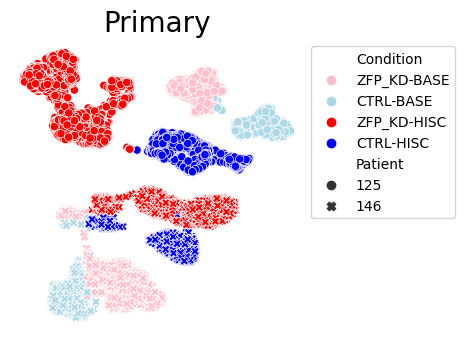

In [88]:
color_labels = {}
for col, i in zip(['blue','red'],['CTRL','ZFP_KD']):
    for shade,j in zip(['light',''],['BASE','HISC']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'


fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata = adata[ind,:]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

# For Post-Processing Concatenated Adata

In [65]:
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/adata.combined.h5ad')

In [66]:
ref_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/'

In [67]:
sample_df = pd.read_csv(ref_dir + 'Organoid_Sample_Description.txt', sep='\t',index_col=0)

In [68]:
mtx_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' +  'scran_output_matrix.mtx'
g_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_genes.csv'
bc_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_barcodes.csv'

In [69]:
fn = g_fn
with open(fn, 'r') as f:
    g = [i.strip() for i in f.readlines()]

fn = bc_fn
with open(fn, 'r') as f:
    bc = [i.strip() for i in f.readlines()]

In [70]:
norm_df = mmread(mtx_fn)
norm_df = norm_df.tocsr().toarray()
norm_df = pd.DataFrame(norm_df, index=bc, columns=g)

In [71]:
samples = [re.sub('_[ACGT]+-1$','',i) for i in bc]
samples = pd.Series(samples, index = bc)

In [72]:
bc_intersect = adata.obs.index.intersection(norm_df.index)
g_intersect = adata.var_names.intersection(norm_df.columns)
adata = adata[bc_intersect, g_intersect]

adata.layers["counts"] = adata.X.copy()

norm_df = norm_df.loc[adata.obs.index, adata.var_names]

/scratch/lsftmp/2287533.tmpdir/ipykernel_2363/2665607346.py:5: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [73]:
adata.X = norm_df.values
adata.layers['without_log'] = adata.X
adata.raw = adata  # Save the raw data before log transformation
sc.pp.log1p(adata, base=2)

In [74]:
sample_df2 = sample_df.loc[samples,:]
sample_df2.index = adata.obs.index

adata.obs = pd.concat([adata.obs.drop('Sample', axis=1), sample_df2], axis=1)

adata.obs['Sample'] = adata.obs['Sample'].astype('category')

In [75]:
adata.obs['Batch'] = adata.obs.Batch.astype(str).astype('category')

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Batch"
)

norm_df = pd.DataFrame(adata.X, index=adata.obs_names, columns = adata.var_names)
norm_df = norm_df.loc[:,adata.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [76]:
import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)
    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [77]:
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values
adata.uns['num_components'] = num_components
adata.uns['var_explained'] = var_explained

Performing PCA
# Components = 43
Variance explained = 0.385391


In [78]:
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

Performing nearest neighbors


In [79]:
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata.obs['phenograph'] = clusters_merge.loc[adata.obs_names].astype('str').astype('category')

Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 2.9911532402038574 seconds
Jaccard graph constructed in 16.05109930038452 seconds
Wrote graph to binary file in 0.6411418914794922 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.957551
Louvain completed 21 runs in 32.29726791381836 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 59.10530924797058 seconds


In [80]:
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata, groups = 'phenograph')
sc.pl.paga(adata, plot=False)
sc.tl.umap(adata, init_pos='paga', min_dist=min_dist)

Performing UMAP


In [61]:
adata

AnnData object with n_obs × n_vars = 59140 × 32491
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'num_components', 'var_explained', 'neighbors', 'paga', 'phenograph_sizes', 'umap'
    obsm: 'gene_expression_encoding', 'X_pca', 'X_umap'
    layers: 'counts', 'without_log'
 

In [62]:
# Save the post-processed adata 

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

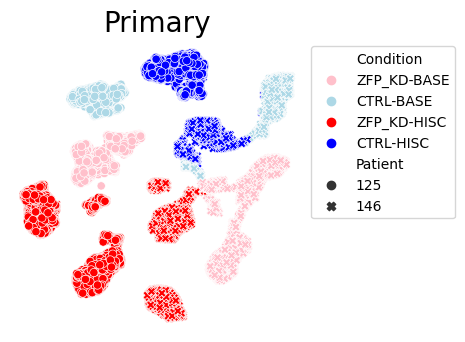

In [81]:
# Plot the post-processed adata
color_labels = {}
for col, i in zip(['blue','red'],['CTRL','ZFP_KD']):
    for shade,j in zip(['light',''],['BASE','HISC']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'


fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata = adata[ind,:]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)